<a href="https://colab.research.google.com/github/monishkollimarla/Predictive-Analysis/blob/House-hold-Prediction/full_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving data.csv to data.csv
Mean Squared Error: 989173788718.9497
R² Score: 0.03007565959925851


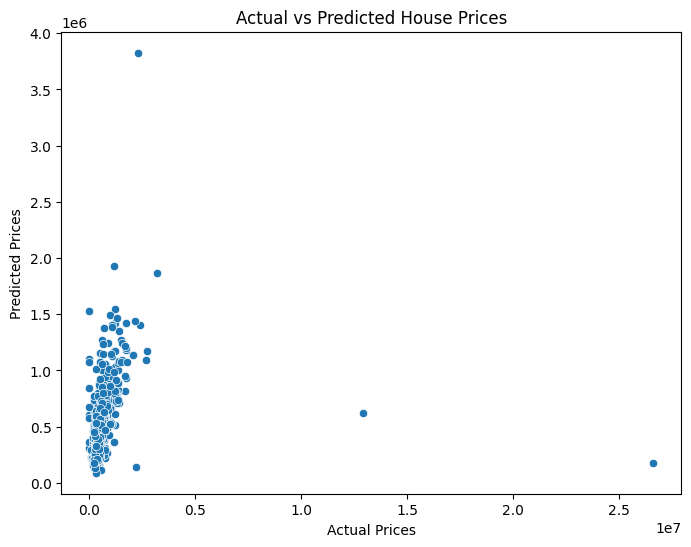

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import io

# Load the dataset
from google.colab import files
uploaded = files.upload()

# Assuming the uploaded file is named 'data.csv' as per the output
file_name = list(uploaded.keys())[0]
data = pd.read_csv(io.BytesIO(uploaded[file_name]))

# Select features and target variable
features = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'yr_built']
target = 'price'

X = data[features]
y = data[target]

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R² Score: {r2}')

# Visualize actual vs predicted prices
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted House Prices')
plt.show()

Saving Python1.csv to Python1 (2).csv


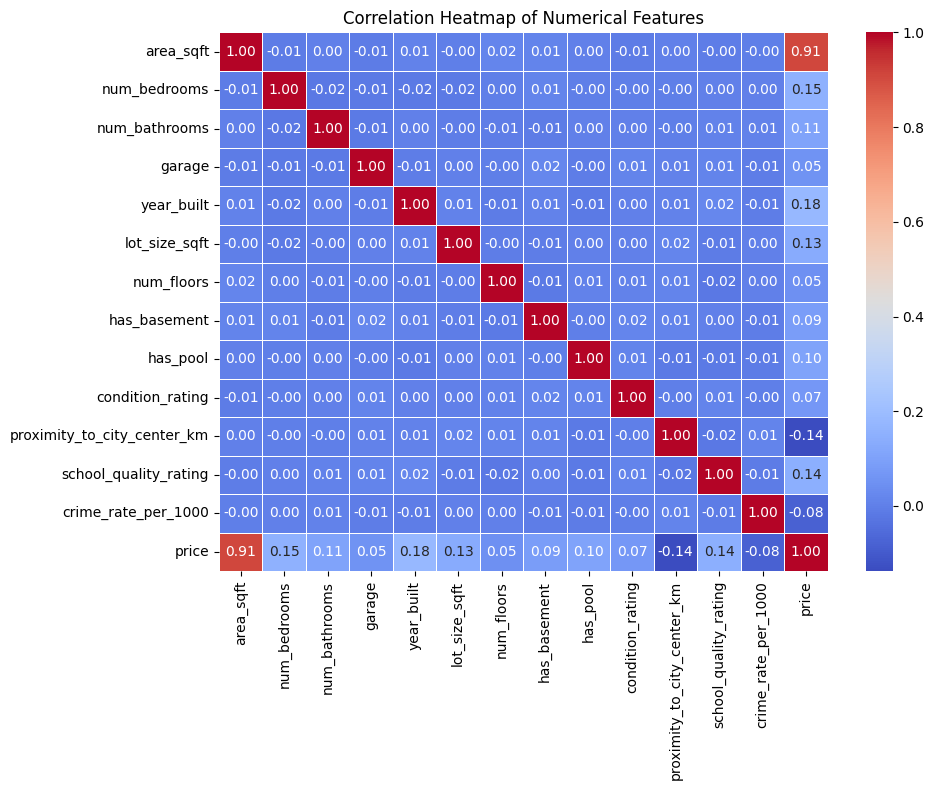

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import io
from google.colab import files
uploaded = files.upload()
# Load your dataset (replace with your file path or DataFrame)
file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))  # or use your DataFrame directly

# Select only numerical columns
numerical_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr_matrix = numerical_df.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()
%matplotlib inline

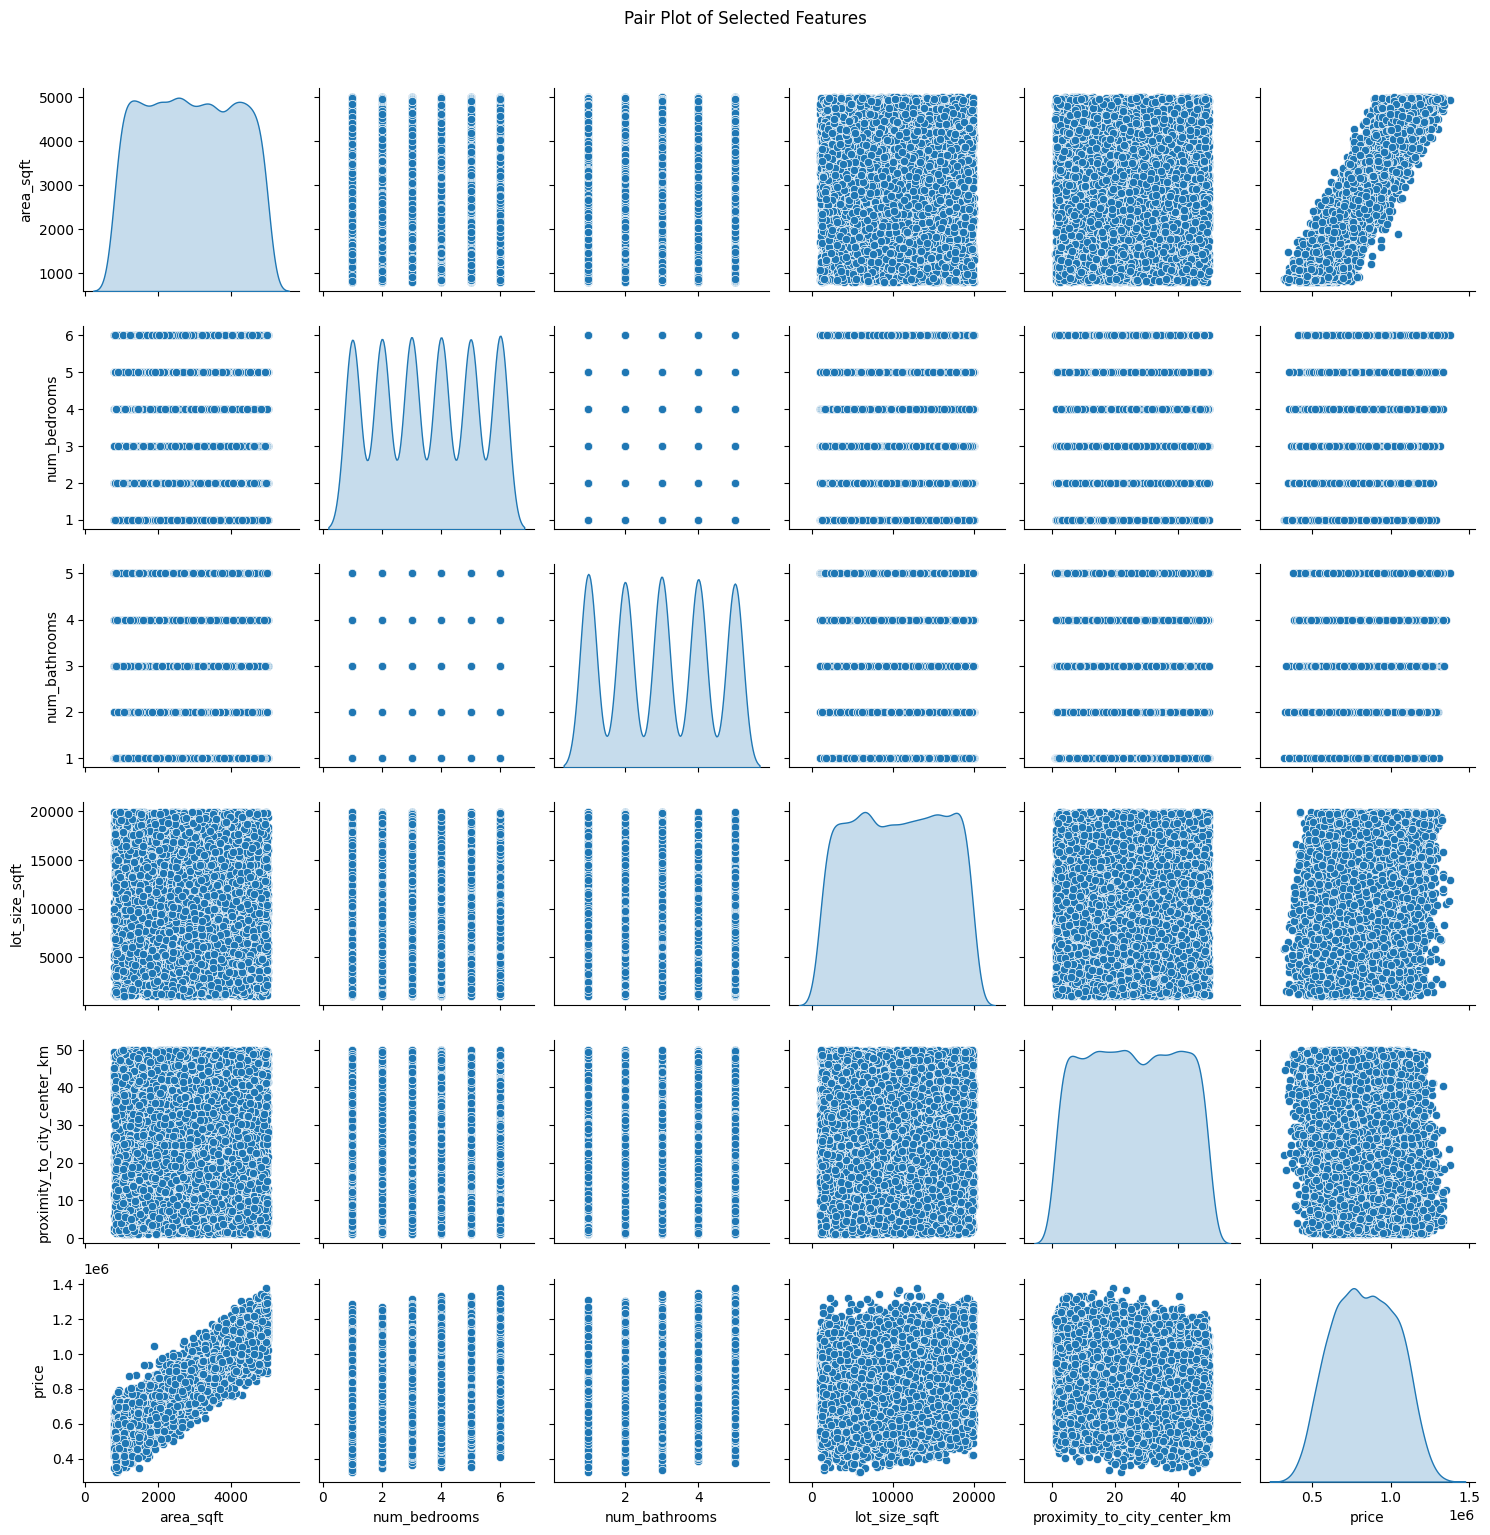

In [7]:


# Select a few important numerical features for the pair plot
selected_features = ['area_sqft', 'num_bedrooms', 'num_bathrooms',
                     'lot_size_sqft', 'proximity_to_city_center_km', 'price']

# Create the pair plot
sns.pairplot(df[selected_features], diag_kind='kde')


plt.suptitle('Pair Plot of Selected Features', y=1.02)
plt.tight_layout()
plt.show()

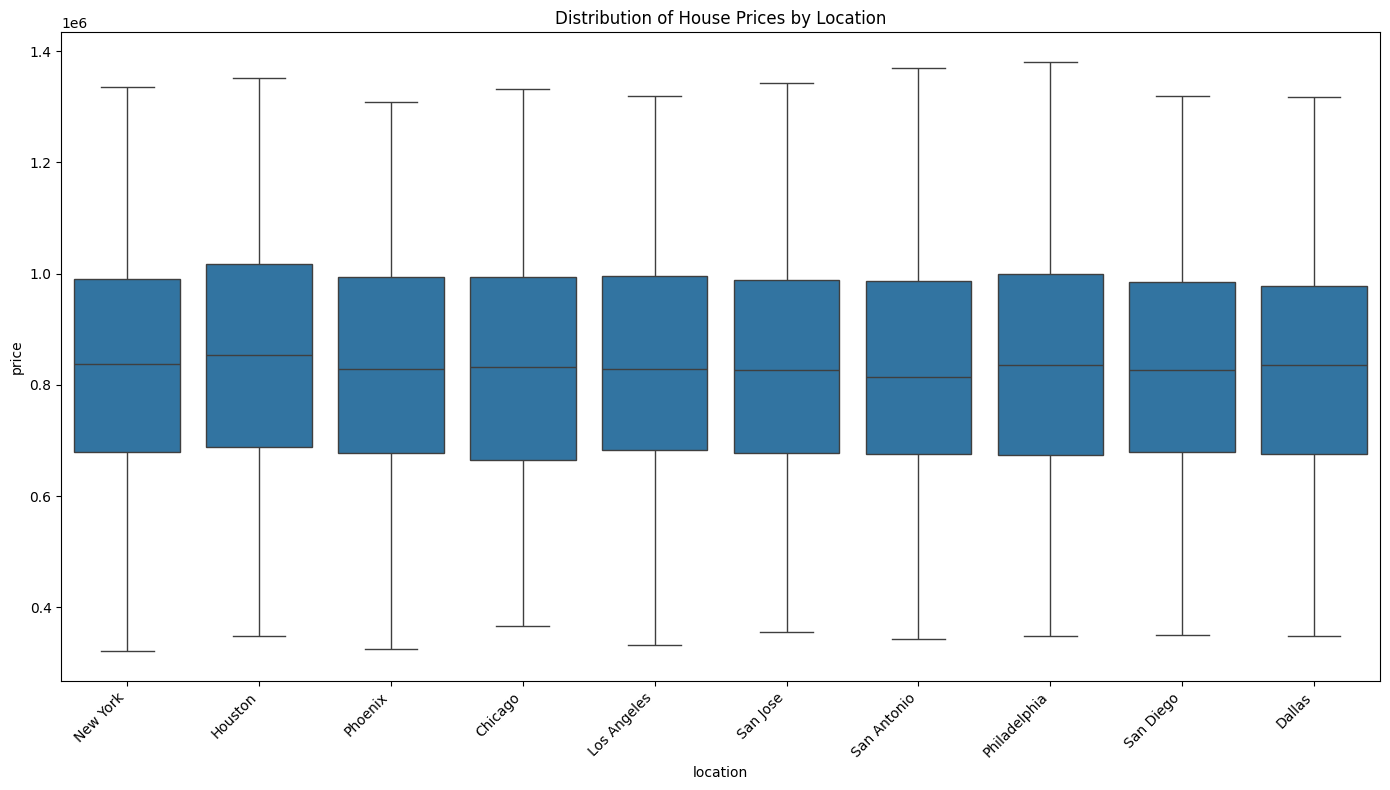

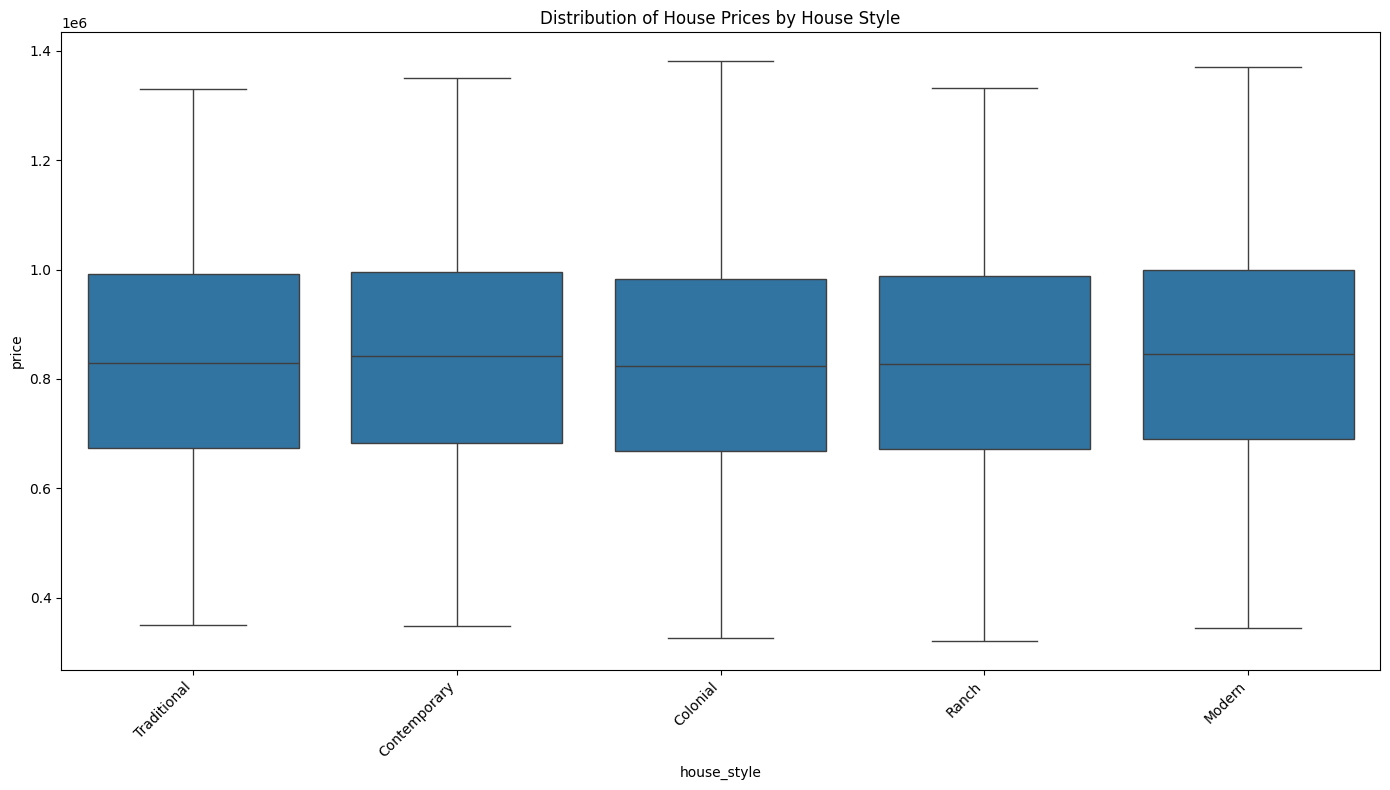

In [8]:
plt.figure(figsize=(14, 8))
sns.boxplot(data=df, x='location', y='price')
plt.xticks(rotation=45, ha='right')
plt.title('Distribution of House Prices by Location')
plt.tight_layout()
plt.show()

# ── 2. Box plot: Price vs House Style ─────────────────────────────────────────
plt.figure(figsize=(14, 8))
sns.boxplot(data=df, x='house_style', y='price')
plt.xticks(rotation=45, ha='right')
plt.title('Distribution of House Prices by House Style')
plt.tight_layout()
plt.show()

/tmp/ipython-input-9-331176004.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price'], bins=50, kde=True, color='skyblue')


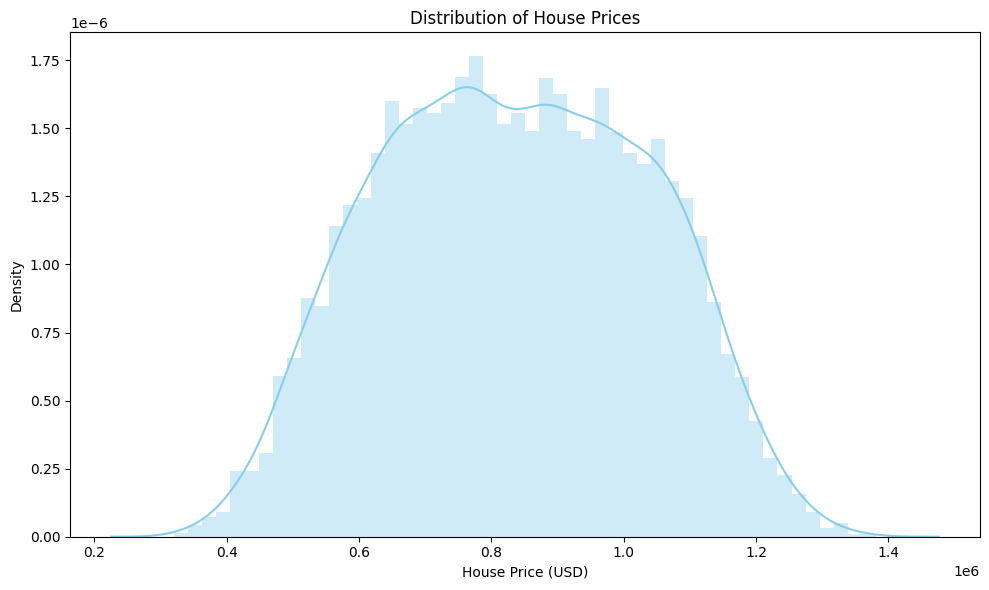

In [9]:
# Use distplot instead of histplot
plt.figure(figsize=(10, 6))
sns.distplot(df['price'], bins=50, kde=True, color='skyblue')

plt.title('Distribution of House Prices')
plt.xlabel('House Price (USD)')
plt.ylabel('Density')
plt.tight_layout()
plt.show()


/tmp/ipython-input-11-1637005274.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=feat_imp_df.head(20), x='Importance', y='Feature', palette='viridis')


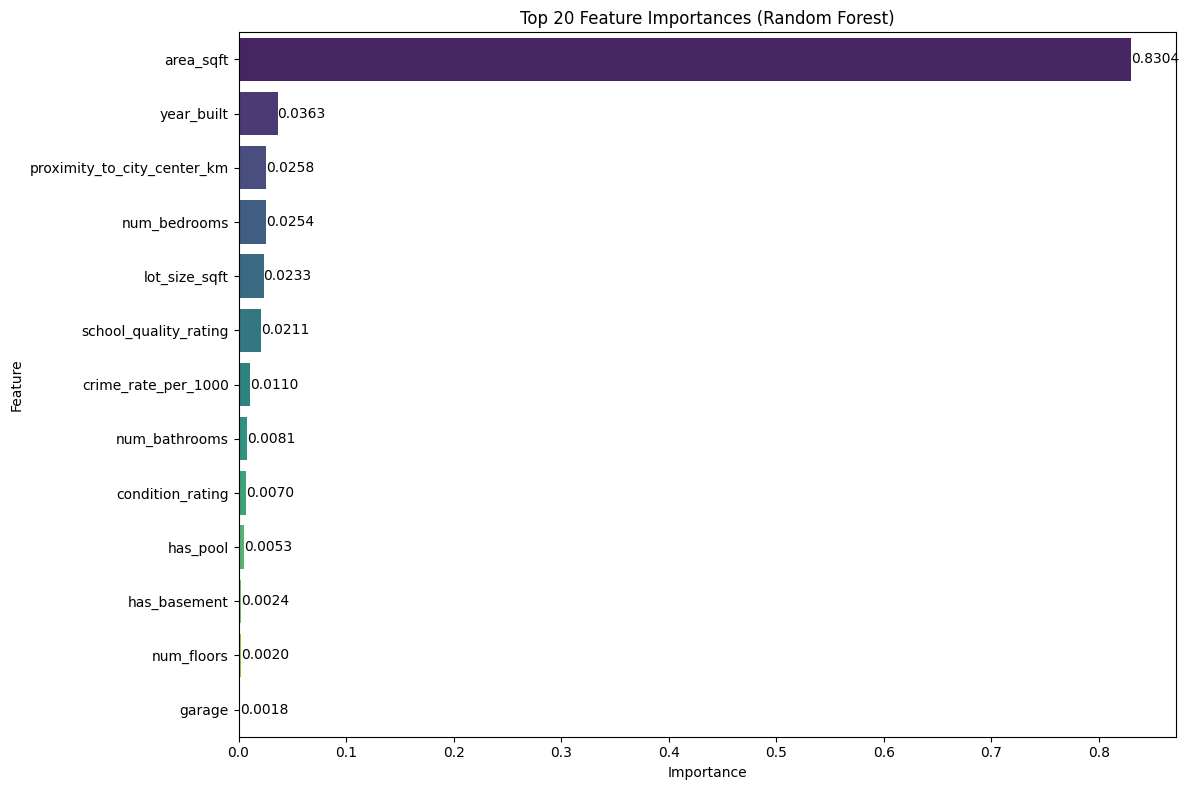

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# ───────────────────────────────────────

# Encode categorical columns
df_encoded = pd.get_dummies(df, drop_first=True)

# Drop object (non-numeric) columns (if any remain accidentally)
df_encoded = df_encoded.select_dtypes(include=[np.number])

# Drop rows where 'price' is missing
df_encoded = df_encoded.dropna(subset=['price'])

# Separate features and target
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

# Replace infinite values in NumPy (efficient)
X = np.where(np.isfinite(X), X, np.nan)

# Impute missing values
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42
)

# Train model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Feature importance
importances = model.feature_importances_
feature_names = df_encoded.drop('price', axis=1).columns

# Prepare for plotting
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(12, 8))
ax = sns.barplot(data=feat_imp_df.head(20), x='Importance', y='Feature', palette='viridis')
plt.title('Top 20 Feature Importances (Random Forest)')
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', label_type='edge')
plt.tight_layout()
plt.show()